# Evaluasi Akhir Model
## 05 — Menguji Kandidat Terkunci pada Data Holdout

**Proyek:** Prediksi Muka Air Tanah Satu Minggu ke Depan · **Studi kasus:** Drenthe, Belanda · **Penyusun:** Rasen

Pada notebook 01–03, saya menetapkan masalah, memahami pola, dan menyiapkan fitur historis. Pada notebook 04, saya membandingkan model serta melakukan tuning menggunakan data pengembangan. Kandidat dan kelompok fiturnya sudah dipilih sebelum tahap ini.

Sekarang saya mengukur hasil pada periode holdout mulai 1 Januari 2017. Pertanyaannya tetap sama: apakah kandidat yang dipilih mampu memprediksi head minggu depan lebih baik daripada menggunakan head minggu ini sebagai perkiraan?

**Alur notebook:** memeriksa file → membuka holdout → menghasilkan prediksi → membandingkan baseline → memeriksa kesalahan → menyimpan hasil untuk laporan dan dashboard.

### Cara menjalankan

1. Simpan notebook ini sebagai `notebooks/05_evaluasi_akhir.ipynb` di proyek `groundwater_forecasting`.
2. Pastikan notebook 03 dan 04 sudah berhasil dijalankan sampai selesai. Model yang dimuat adalah file yang dibuat sendiri oleh notebook 04.
3. Gunakan kernel yang sama dengan notebook 04, lalu jalankan semua cell dari atas ke bawah.
4. Hasil akan disimpan di `outputs/evaluation`. Notebook ini tidak melatih ulang model dan tidak mengubah file notebook 01–04, model, atau data sumber.

Output dalam file ini dikosongkan agar hasil yang tampil berasal dari model di laptop saya. Nama algoritma dan skor tidak ditulis tetap dalam kode; semuanya dibaca atau dihitung dari hasil yang benar-benar tersedia.

**Aturan evaluasi:** hasil holdout digunakan untuk pelaporan, bukan untuk mencoba parameter berulang kali. Mengulang notebook dengan model dan data yang sama hanya mereproduksi hasil yang sama, bukan menciptakan data uji baru.


## 1. Menjaga Hubungan dengan Notebook Sebelumnya

| File masukan | Asal | Fungsinya |
| --- | --- | --- |
| `netherlands_holdout.csv` | Notebook 03 | Sampel uji yang memiliki fitur dan target lengkap |
| `netherlands_development.csv` | Notebook 03 | Acuan rentang fitur latihan untuk diagnosis |
| `netherlands_supervised_calendar.csv` | Notebook 03 | Kalender lengkap untuk memeriksa cakupan |
| `feature_schema.json` | Notebook 03 | Definisi target, kelompok fitur, dan identitas data |
| `groundwater_ml_candidate.joblib` | Notebook 04 | Pipeline terlatih beserta metadata pemilihannya |
| `model_metadata.json` | Notebook 04 | Salinan metadata yang bisa dibaca tanpa membuka model |

Model yang dimuat bisa berbeda antarperangkat atau versi pustaka, sehingga notebook ini tidak memaksa algoritma tertentu sebagai pemenang. Yang diperiksa adalah konsistensi model, fitur, dan data yang digunakan.

Checksum dipakai sebagai sidik jari file. Jika CSV berubah sejak feature engineering, kode berhenti supaya hasil evaluasi tidak diam-diam memakai versi data yang berbeda.


In [1]:
from pathlib import Path
from datetime import datetime, timezone
import json
import hashlib
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib
import sklearn
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

kandidat_folder = [Path.cwd(), *Path.cwd().parents,
    Path.home()/"Downloads"/"Rasen_Portofolio"/"02_Projects"/"groundwater_forecasting"]
PROJECT_DIR = next((p for p in kandidat_folder
    if (p/"data/processed/feature_schema.json").is_file()), None)
if PROJECT_DIR is None:
    raise FileNotFoundError("Folder proyek belum ditemukan. Buka notebook dari proyek groundwater_forecasting.")
DATA_DIR = PROJECT_DIR/"data/processed"
MODEL_DIR = PROJECT_DIR/"models"
OUTPUT_DIR = PROJECT_DIR/"outputs/evaluation"
file_model = MODEL_DIR/"groundwater_ml_candidate.joblib"
file_meta = MODEL_DIR/"model_metadata.json"
file_schema = DATA_DIR/"feature_schema.json"
file_holdout = DATA_DIR/"netherlands_holdout.csv"
file_dev = DATA_DIR/"netherlands_development.csv"
file_kalender = DATA_DIR/"netherlands_supervised_calendar.csv"
for file in [file_model, file_meta, file_schema, file_holdout, file_dev, file_kalender]:
    if not file.is_file():
        raise FileNotFoundError(f"{file.name} belum tersedia. Selesaikan notebook 03 dan 04 terlebih dahulu.")

def sha256(file):
    return hashlib.sha256(file.read_bytes()).hexdigest()

skema = json.loads(file_schema.read_text(encoding="utf-8"))
metadata_json = json.loads(file_meta.read_text(encoding="utf-8"))
assert sha256(file_holdout) == skema["holdout_sha256"], "Versi holdout tidak cocok dengan skema notebook 03."
assert sha256(file_dev) == skema["development_sha256"], "Versi pengembangan tidak cocok dengan skema notebook 03."
assert metadata_json["feature_schema"] == skema, "Model dan skema berasal dari proses berbeda."
if sklearn.__version__ != metadata_json["versions"]["sklearn"]:
    raise RuntimeError(
        f"Versi scikit-learn sekarang {sklearn.__version__}, sedangkan model dibuat dengan "
        f"{metadata_json['versions']['sklearn']}. Gunakan kernel yang sama seperti saat menjalankan notebook 04."
    )
paket = joblib.load(file_model)
model = paket["pipeline"]
metadata = paket["metadata"]
# Parameter seperti hidden_layer_sizes adalah tuple di model, tetapi list di JSON.
assert json.loads(json.dumps(metadata)) == metadata_json, "Metadata di model dan JSON tidak sama."
FITUR = metadata["feature_columns"]
TARGET = metadata["target_column"]
BATAS_HOLDOUT = pd.Timestamp(metadata["holdout_target_start"])
assert FITUR == skema["feature_groups"][metadata["feature_group"]]
assert metadata["horizon_weeks"] == skema["horizon_weeks"] == 1
assert metadata["holdout_target_start"] == skema["holdout_target_start"]
assert TARGET == skema["target_column"] and TARGET not in FITUR
assert len(FITUR) == len(set(FITUR))
if hasattr(model, "feature_names_in_"):
    assert list(model.feature_names_in_) == FITUR, "Urutan fitur pipeline berbeda."

print("Kandidat terkunci:", metadata["experiment_id"])
print("Algoritma:", metadata["model_family"])
print("Kelompok fitur:", metadata["feature_group"], "—", len(FITUR), "fitur")
print("Akhir target latihan:", metadata["fit_target_end"])
print("Batas target holdout:", BATAS_HOLDOUT.date())
print("Rekomendasi dari validasi:", metadata["provisional_recommendation"])


Kandidat terkunci: tuning_MLP_3
Algoritma: MLP
Kelompok fitur: head_weather — 19 fitur
Akhir target latihan: 2016-12-18
Batas target holdout: 2017-01-01
Rekomendasi dari validasi: kandidat_ml


## 2. Membuka Holdout dan Memeriksa Cakupan

Tanggal yang digunakan untuk membagi data adalah `target_date`. `forecast_date` menunjukkan akhir minggu ketika prediksi dibuat, tepat satu minggu sebelumnya.

Jumlah sampel tidak dipaksa menjadi 204 di dalam kode. Angka tersebut merupakan hasil pada dataset yang sudah digunakan sebelumnya; notebook tetap menghitung dan memeriksa file yang tersedia.

Tabel cakupan membedakan minggu kalender, target yang benar-benar tersedia, dan sampel yang lengkap untuk model. Minggu di luar akhir kalender sumber tidak dihitung sebagai periode uji. Hasil evaluasi hanya berlaku pada sampel yang bisa dinilai, bukan otomatis pada semua minggu yang hilang.


In [2]:
holdout = pd.read_csv(file_holdout, parse_dates=["forecast_date", "target_date"])
holdout = holdout.sort_values("target_date").reset_index(drop=True)
dev = pd.read_csv(file_dev, parse_dates=["forecast_date", "target_date"])
kalender = pd.read_csv(file_kalender, parse_dates=["forecast_date", "target_date"])
kolom_wajib = ["forecast_date", "target_date", TARGET, "baseline_persistence", "baseline_seasonal_52w", *FITUR]
assert set(kolom_wajib).issubset(holdout.columns)
assert not holdout.empty and not holdout["target_date"].duplicated().any()
assert holdout[["forecast_date", "target_date"]].notna().all().all()
assert holdout["target_date"].ge(BATAS_HOLDOUT).all()
assert (holdout["target_date"] - holdout["forecast_date"]).eq(pd.Timedelta(weeks=1)).all()
assert pd.Timestamp(metadata["fit_target_end"]) < holdout["forecast_date"].min()
assert holdout[FITUR + [TARGET, "baseline_persistence"]].notna().all().all()
assert np.isfinite(holdout[FITUR + [TARGET, "baseline_persistence"]].to_numpy()).all()
assert dev["target_date"].lt(BATAS_HOLDOUT).all()
np.testing.assert_allclose(holdout["baseline_persistence"], holdout["head_t"])

# Cocokkan baris holdout dengan kalender hasil notebook 03.
assert not kalender["target_date"].duplicated().any()
acuan = kalender.set_index("target_date").loc[holdout["target_date"]]
np.testing.assert_allclose(acuan[FITUR + [TARGET]].to_numpy(), holdout[FITUR + [TARGET]].to_numpy())
akhir_kalender = kalender["forecast_date"].max()
kalender_uji = kalender.loc[kalender["target_date"].between(BATAS_HOLDOUT, akhir_kalender)].copy()
n_target_ada = int(kalender_uji[TARGET].notna().sum())
tabel_cakupan = pd.DataFrame([{
    "awal_target_kalender": kalender_uji["target_date"].min().date(),
    "akhir_target_kalender": kalender_uji["target_date"].max().date(),
    "minggu_kalender": len(kalender_uji),
    "target_tersedia": n_target_ada,
    "sampel_dinilai": len(holdout),
    "persen_dari_kalender": 100*len(holdout)/len(kalender_uji),
    "persen_dari_target_tersedia": 100*len(holdout)/n_target_ada
}])
display(tabel_cakupan.round(2))
print("Target sampel yang dinilai:", holdout["target_date"].min().date(), "sampai", holdout["target_date"].max().date())


,awal_target_kalender,akhir_target_kalender,minggu_kalender,target_tersedia,sampel_dinilai,persen_dari_kalender,persen_dari_target_tersedia
0,2017-01-01,2020-11-29,205,204,204,99.51,100.0


Target sampel yang dinilai: 2017-01-01 sampai 2020-11-22


## 3. Menghasilkan Prediksi dari Model yang Sudah Terkunci

Pada tahap ini hanya digunakan `predict()`. Tidak ada `fit()`, tuning, atau pemilihan fitur baru. Pipeline yang dimuat menjalankan transformasi input yang sudah dipelajari dari data latihan.

Evaluasi bersifat **satu minggu ke depan secara bergulir**. Saat memprediksi minggu berikutnya, observasi minggu yang baru selesai sudah boleh menjadi input. Modelnya tetap sama; input historisnya diperbarui mengikuti tanggal. Ini bukan ramalan empat tahun sekaligus dari akhir 2016.

Prediksi tidak dipotong mengikuti rentang aktual holdout. Jika hasilnya meleset, kesalahan itu tetap dicatat. Catatan evaluasi menyimpan identitas model dan data. Pengulangan dengan kombinasi yang sama diperbolehkan untuk reproduksi; kombinasi berbeda tidak boleh diam-diam menggantikan evaluasi sebelumnya.


In [3]:
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
file_catatan = OUTPUT_DIR/"evaluation_record.json"
identitas = {"model_sha256": sha256(file_model), "holdout_sha256": sha256(file_holdout),
    "schema_sha256": sha256(file_schema), "experiment_id": metadata["experiment_id"]}
if file_catatan.is_file():
    catatan_lama = json.loads(file_catatan.read_text(encoding="utf-8"))
    if catatan_lama.get("identity") != identitas:
        raise RuntimeError(
            "Sudah ada catatan evaluasi dengan model/data berbeda. Jangan menimpa hasil lama. "
            "Tinjau riwayat eksperimen dahulu; holdout yang sudah dilihat tidak menjadi data uji baru."
        )
    waktu_mulai = catatan_lama["first_evaluation_utc"]
    print("Mengulang evaluasi untuk model dan data yang sama.")
else:
    waktu_mulai = datetime.now(timezone.utc).isoformat()
catatan = {"identity": identitas, "first_evaluation_utc": waktu_mulai,
    "status": "started", "holdout_evaluated": False,
    "selection_source": "development CV from notebook 04"}
file_catatan.write_text(json.dumps(catatan, indent=2), encoding="utf-8")

prediksi_ml = np.asarray(model.predict(holdout[FITUR]), dtype=float).reshape(-1)
assert len(prediksi_ml) == len(holdout) and np.isfinite(prediksi_ml).all()
hasil = holdout[["forecast_date", "target_date", TARGET,
    "baseline_persistence", "baseline_seasonal_52w"]].copy()
hasil = hasil.rename(columns={TARGET: "aktual_head_m"})
hasil["prediksi_ml_m"] = prediksi_ml
hasil["residual_ml_m"] = hasil["aktual_head_m"] - hasil["prediksi_ml_m"]
hasil["absolute_error_ml_m"] = hasil["residual_ml_m"].abs()
hasil["absolute_error_persistence_m"] = (hasil["aktual_head_m"] - hasil["baseline_persistence"]).abs()
display(hasil.head().round(4))


,forecast_date,target_date,aktual_head_m,baseline_persistence,baseline_seasonal_52w,prediksi_ml_m,residual_ml_m,absolute_error_ml_m,absolute_error_persistence_m
0,2016-12-25,2017-01-01,11.2486,11.2529,NaN,11.2671,-0.0185,0.0185,0.0043
1,2017-01-01,2017-01-08,11.2471,11.2486,NaN,11.2590,-0.0119,0.0119,0.0014
2,2017-01-08,2017-01-15,11.2814,11.2471,NaN,11.2621,0.0194,0.0194,0.0343
3,2017-01-15,2017-01-22,11.2700,11.2814,NaN,11.2976,-0.0276,0.0276,0.0114
4,2017-01-22,2017-01-29,11.2471,11.2700,NaN,11.2610,-0.0139,0.0139,0.0229


## 4. Evaluasi Utama: Kandidat ML dan Persistence

Kedua metode dinilai pada tanggal target yang sama. MAE menjadi metrik utama sesuai rencana awal. RMSE, R², bias, dan persentil kesalahan melengkapi gambaran kinerja.

| Metrik | Cara membaca |
| --- | --- |
| MAE | Rata-rata kesalahan absolut; makin kecil makin baik |
| RMSE | Lebih memberi bobot pada kesalahan besar |
| R² | Perbandingan terhadap variasi aktual; dapat negatif, bukan persentase akurasi |
| Bias | Rata-rata prediksi dikurangi aktual; positif berarti cenderung terlalu tinggi |
| P90 absolute error | Sekitar 90% kesalahan absolut sampel berada pada atau di bawah angka ini |
| Skill terhadap persistence | Persentase pengurangan MAE dibanding persistence; negatif berarti lebih buruk |

Meter juga ditampilkan sebagai sentimeter supaya besar kesalahan mudah dibayangkan. P90 ini merupakan statistik kesalahan yang teramati, **bukan** jaminan interval prediksi 90% untuk masa depan.


In [4]:
def metrik(y, pred):
    y, pred = np.asarray(y, dtype=float), np.asarray(pred, dtype=float)
    assert len(y) == len(pred) and len(y) > 0
    assert np.isfinite(y).all() and np.isfinite(pred).all()
    ae = np.abs(y-pred)
    mae = float(mean_absolute_error(y, pred))
    return {"n": len(y), "MAE_m": mae, "MAE_cm": 100*mae,
        "RMSE_m": float(np.sqrt(mean_squared_error(y, pred))),
        "R2": float(r2_score(y, pred)) if len(y)>1 and np.var(y)>0 else np.nan,
        "bias_pred_minus_actual_m": float(np.mean(pred-y)),
        "P90_absolute_error_m": float(np.quantile(ae, .9)),
        "max_absolute_error_m": float(ae.max())}

metrik_ml = metrik(hasil["aktual_head_m"], hasil["prediksi_ml_m"])
metrik_persist = metrik(hasil["aktual_head_m"], hasil["baseline_persistence"])
def skill(mae, baseline):
    return 100*(1-mae/baseline) if baseline > 0 else np.nan
skor_utama = pd.DataFrame([
    {"metode": "Kandidat ML terkunci", **metrik_ml},
    {"metode": "Persistence", **metrik_persist}
])
skor_utama["skill_MAE_vs_persistence_pct"] = skor_utama["MAE_m"].map(lambda nilai: skill(nilai, metrik_persist["MAE_m"]))
display(skor_utama.round(4))
print("Algoritma kandidat ML:", metadata["model_family"])
print("Metrik dihitung pada tanggal yang identik untuk kedua metode.")


,metode,n,MAE_m,MAE_cm,RMSE_m,R2,bias_pred_minus_actual_m,P90_absolute_error_m,max_absolute_error_m,skill_MAE_vs_persistence_pct
0,Kandidat ML terkunci,204,0.0374,3.7384,0.0493,0.9431,0.0191,0.0854,0.1540,4.1576
1,Persistence,204,0.0390,3.9006,0.0638,0.9046,0.0002,0.0834,0.4871,0.0000


Algoritma kandidat ML: MLP
Metrik dihitung pada tanggal yang identik untuk kedua metode.


## 5. Baseline Musiman pada Irisan Tanggal

Seasonal naïve menggunakan nilai 52 minggu sebelum minggu target. Karena ada celah riwayat, baseline ini belum tentu tersedia pada semua tanggal holdout.

Saya menghitung kembali ketiga metode hanya pada tanggal ketika baseline musiman tersedia. Tabel ini memiliki cakupan berbeda dari tabel utama. Jangan membandingkan MAE musiman di sini dengan MAE ML dari tabel utama tanpa menyamakan tanggalnya.


In [5]:
mask_musiman = hasil["baseline_seasonal_52w"].notna()
irisan = hasil.loc[mask_musiman].copy()
kolom_metode = {"Kandidat ML terkunci": "prediksi_ml_m", "Persistence": "baseline_persistence",
    "Seasonal naive 52w": "baseline_seasonal_52w"}
rekaman_irisan = []
if len(irisan):
    for nama, kolom in kolom_metode.items():
        rekaman_irisan.append({"metode": nama, **metrik(irisan["aktual_head_m"], irisan[kolom])})
skor_irisan = pd.DataFrame(rekaman_irisan, columns=["metode", *metrik_ml.keys()])
print("Baseline musiman tersedia:", len(irisan), "dari", len(hasil), "sampel holdout.")
if len(irisan):
    display(skor_irisan.round(4))
else:
    print("Tidak ada pasangan musiman yang dapat dinilai; skor musiman tidak dihitung.")


Baseline musiman tersedia: 165 dari 204 sampel holdout.


,metode,n,MAE_m,MAE_cm,RMSE_m,R2,bias_pred_minus_actual_m,P90_absolute_error_m,max_absolute_error_m
0,Kandidat ML terkunci,165,0.0387,3.8662,0.0505,0.9471,0.0218,0.0870,0.1540
1,Persistence,165,0.0408,4.0771,0.0671,0.9067,0.0002,0.0889,0.4871
2,Seasonal naive 52w,165,0.1577,15.7749,0.2285,-0.0838,0.0310,0.4454,0.6400


## 6. Grafik Aktual, Prediksi, dan Residual

Grafik membantu melihat kapan model mengikuti perubahan dan kapan kesalahannya membesar. Garis menggunakan kalender mingguan lengkap, sehingga tanggal tanpa prediksi tetap menjadi celah.

Residual didefinisikan sebagai **aktual dikurangi prediksi**. Residual positif berarti model memprediksi terlalu rendah. Ini kebalikan tanda kolom bias pada tabel metrik, yang didefinisikan sebagai prediksi dikurangi aktual.

Garis putus-putus pada scatter plot adalah prediksi sempurna, yaitu prediksi sama dengan aktual. Titik yang jauh dari garis tersebut memiliki kesalahan lebih besar. Tampilan grafik perlu dibaca bersama angka evaluasi, bukan menjadi pengganti metrik.


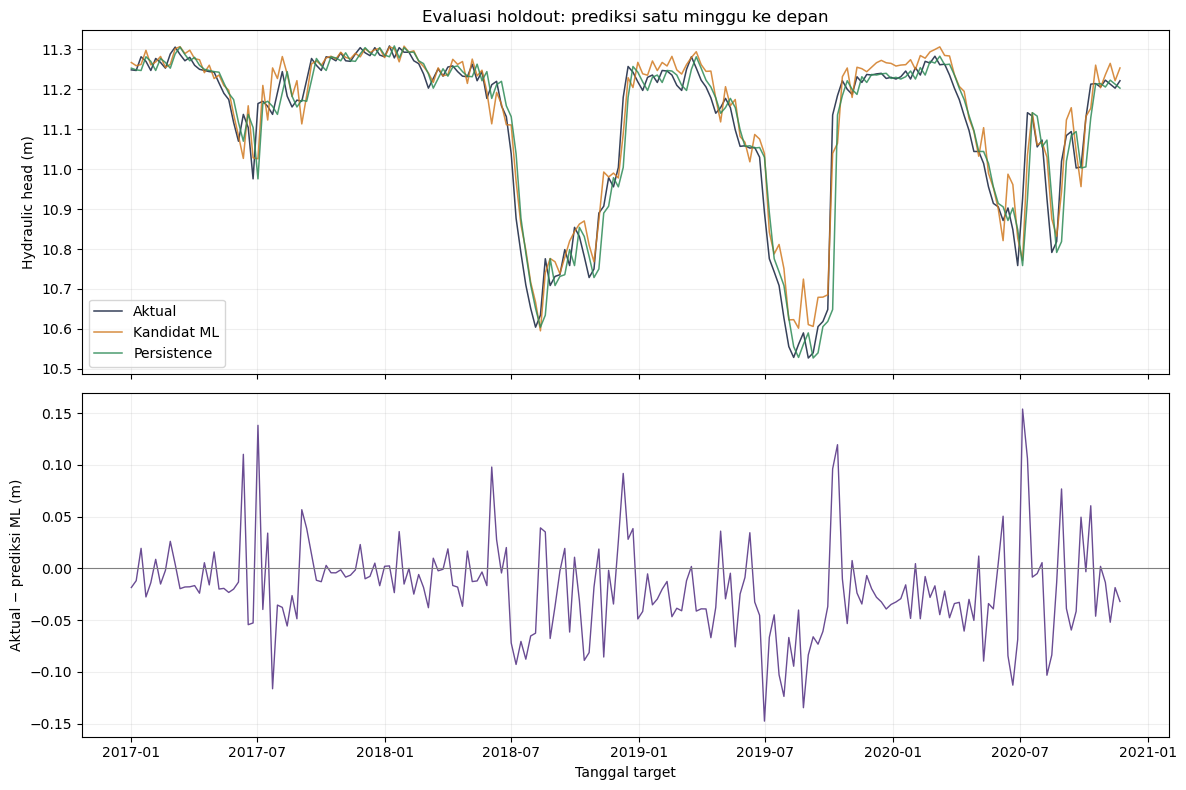

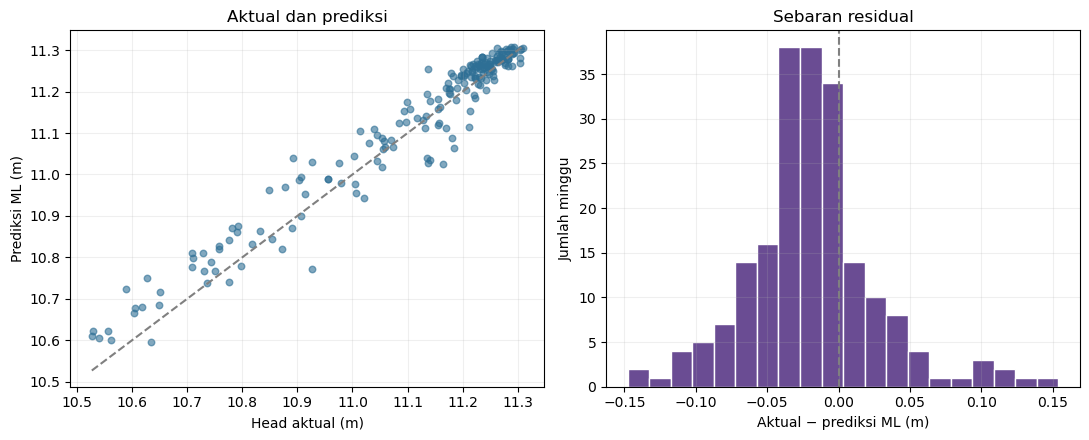

In [6]:
def simpan_grafik(fig, nama):
    fig.tight_layout()
    fig.savefig(OUTPUT_DIR/nama, dpi=160, bbox_inches="tight")
    plt.show()
    plt.close(fig)

seri = hasil.set_index("target_date").reindex(pd.date_range(
    kalender_uji["target_date"].min(), kalender_uji["target_date"].max(), freq="W-SUN"))
fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)
for kolom, nama, warna in [("aktual_head_m", "Aktual", "#14213D"),
    ("prediksi_ml_m", "Kandidat ML", "#D17A22"), ("baseline_persistence", "Persistence", "#2E8B57")]:
    axes[0].plot(seri.index, seri[kolom], label=nama, color=warna, linewidth=1.1, alpha=.85)
axes[0].set(title="Evaluasi holdout: prediksi satu minggu ke depan", ylabel="Hydraulic head (m)")
axes[0].legend()
axes[1].plot(seri.index, seri["residual_ml_m"], color="#6A4C93", linewidth=1)
axes[1].axhline(0, color="grey", linewidth=.8)
axes[1].set(xlabel="Tanggal target", ylabel="Aktual − prediksi ML (m)")
for ax in axes: ax.grid(alpha=.2)
simpan_grafik(fig, "01_prediksi_holdout.png")

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
axes[0].scatter(hasil["aktual_head_m"], hasil["prediksi_ml_m"], s=22, alpha=.6, color="#2E6F95")
lo = min(hasil["aktual_head_m"].min(), hasil["prediksi_ml_m"].min())
hi = max(hasil["aktual_head_m"].max(), hasil["prediksi_ml_m"].max())
axes[0].plot([lo, hi], [lo, hi], "--", color="grey")
axes[0].set(xlabel="Head aktual (m)", ylabel="Prediksi ML (m)", title="Aktual dan prediksi")
axes[1].hist(hasil["residual_ml_m"], bins=20, color="#6A4C93", edgecolor="white")
axes[1].axvline(0, color="grey", linestyle="--")
axes[1].set(xlabel="Aktual − prediksi ML (m)", ylabel="Jumlah minggu", title="Sebaran residual")
for ax in axes: ax.grid(alpha=.2)
simpan_grafik(fig, "02_scatter_residual.png")


## 7. Memeriksa Kesalahan per Tahun dan Minggu yang Sulit

Skor keseluruhan bisa menyembunyikan perbedaan antarperiode. Saya menghitung ulang MAE dan RMSE tiap tahun untuk ML serta persistence pada tanggal yang sama. Tahun terakhir hanya mencakup rentang yang tersedia; jumlah sampelnya ditampilkan.

Sepuluh kesalahan ML terbesar juga ditampilkan. Daftar ini membantu membaca keterbatasan model, bukan alasan menghapus pengamatan yang membuat skor buruk. Penyebab fisik kesalahan tidak bisa disimpulkan hanya dari angka prediksi.


,tahun,metode,n,MAE_cm,RMSE_m,R2
0,2017,Kandidat ML terkunci,53,2.5545,0.0378,0.6882
1,2017,Persistence,53,2.6900,0.0416,0.6225
2,2018,Kandidat ML terkunci,52,3.4560,0.0449,0.9623
3,2018,Persistence,52,4.4780,0.0601,0.9324
4,2019,Kandidat ML terkunci,52,4.7120,0.0582,0.9485
5,2019,Persistence,52,3.9011,0.0786,0.9060
6,2020,Kandidat ML terkunci,47,4.3086,0.0543,0.8648
7,2020,Persistence,47,4.6261,0.0698,0.7763


,target_date,aktual_head_m,prediksi_ml_m,baseline_persistence,residual_ml_m,absolute_error_ml_m,absolute_error_persistence_m
183,2020-07-05,10.9257,10.7717,10.7586,0.1540,0.1540,0.1671
130,2019-06-30,10.8914,11.0391,11.0300,-0.1477,0.1477,0.1386
26,2017-07-02,11.1643,11.0260,10.9757,0.1383,0.1383,0.1886
138,2019-08-25,10.5900,10.7247,10.5614,-0.1347,0.1347,0.0286
134,2019-07-28,10.6271,10.7509,10.7086,-0.1238,0.1238,0.0814
145,2019-10-13,11.1843,11.0647,11.1357,0.1196,0.1196,0.0486
29,2017-07-23,11.1371,11.2535,11.1571,-0.1164,0.1164,0.0200
181,2020-06-21,10.8486,10.9615,10.9029,-0.1129,0.1129,0.0543
23,2017-06-11,11.1371,11.0269,11.0700,0.1102,0.1102,0.0671
184,2020-07-12,11.1414,11.0351,10.9257,0.1063,0.1063,0.2157


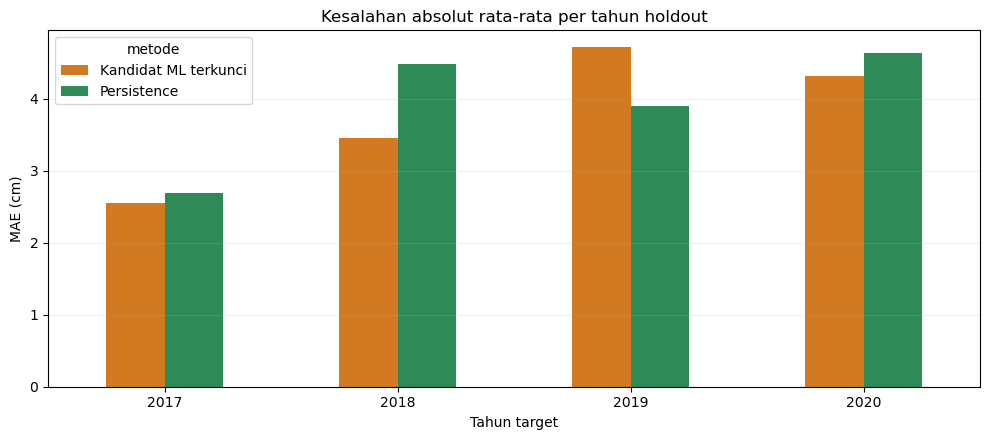

In [7]:
rekaman_tahunan = []
for tahun, bagian in hasil.groupby(hasil["target_date"].dt.year):
    for nama, kolom in [("Kandidat ML terkunci", "prediksi_ml_m"), ("Persistence", "baseline_persistence")]:
        rekaman_tahunan.append({"tahun": int(tahun), "metode": nama,
            **metrik(bagian["aktual_head_m"], bagian[kolom])})
skor_tahunan = pd.DataFrame(rekaman_tahunan)
display(skor_tahunan[["tahun", "metode", "n", "MAE_cm", "RMSE_m", "R2"]].round(4))
terbesar = hasil.nlargest(10, "absolute_error_ml_m").copy()
display(terbesar[["target_date", "aktual_head_m", "prediksi_ml_m", "baseline_persistence",
    "residual_ml_m", "absolute_error_ml_m", "absolute_error_persistence_m"]].round(4))

fig, ax = plt.subplots(figsize=(10, 4.5))
skor_tahunan.pivot(index="tahun", columns="metode", values="MAE_cm").plot.bar(ax=ax, color=["#D17A22", "#2E8B57"])
ax.set(title="Kesalahan absolut rata-rata per tahun holdout", xlabel="Tahun target", ylabel="MAE (cm)")
ax.tick_params(axis="x", rotation=0)
ax.grid(axis="y", alpha=.2)
simpan_grafik(fig, "03_mae_tahunan.png")


## 8. Membandingkan dengan Validasi dan Rentang Latihan

### 8.1 Skor validasi dan holdout

Skor validasi berasal dari beberapa model fold pada periode pengembangan. Skor holdout berasal dari satu pipeline final yang sudah dikunci. Periode, jumlah sampel, dan model terlatihnya berbeda, sehingga perbandingan ini bersifat diagnostik.

Jika skor holdout lebih buruk, penyebabnya tidak otomatis overfitting. Kondisi periode uji, perubahan pola, dan variasi sampel dapat berpengaruh. Sebaliknya, skor holdout yang lebih baik tidak menjamin kemampuan di lokasi lain.

### 8.2 Nilai fitur di luar rentang latihan

Saya membandingkan rentang tiap fitur holdout dengan rentang pada data yang benar-benar dipakai saat fit final. Ini tidak mengubah input atau model. Nilai di luar rentang latihan menjadi penanda bahwa model menghadapi kondisi yang belum tercakup oleh rentang satu fitur tersebut; itu belum membuktikan kesalahan pengukuran atau mendeteksi seluruh bentuk perubahan distribusi.


In [8]:
banding_cv_test = pd.DataFrame([
    {"periode": "CV pengembangan", "metode": "Kandidat ML terkunci", "MAE_m": metadata["cv_MAE_m"], "RMSE_m": metadata["cv_RMSE_m"]},
    {"periode": "Holdout", "metode": "Kandidat ML terkunci", "MAE_m": metrik_ml["MAE_m"], "RMSE_m": metrik_ml["RMSE_m"]},
    {"periode": "CV pengembangan", "metode": "Persistence", "MAE_m": metadata["cv_persistence_MAE_m"], "RMSE_m": np.nan},
    {"periode": "Holdout", "metode": "Persistence", "MAE_m": metrik_persist["MAE_m"], "RMSE_m": metrik_persist["RMSE_m"]}
])
display(banding_cv_test.round(4))

train_final = dev.loc[dev["target_date"] <= pd.Timestamp(metadata["fit_target_end"])].copy()
assert len(train_final) == metadata["n_fit"], "Rekonstruksi periode latihan tidak cocok dengan metadata."
audit_rentang = []
for kolom in FITUR:
    bawah, atas = train_final[kolom].min(), train_final[kolom].max()
    di_luar = holdout[kolom].lt(bawah) | holdout[kolom].gt(atas)
    audit_rentang.append({"fitur": kolom, "min_train": bawah, "max_train": atas,
        "min_holdout": holdout[kolom].min(), "max_holdout": holdout[kolom].max(),
        "n_di_luar_rentang": int(di_luar.sum()), "persen_di_luar_rentang": 100*di_luar.mean()})
audit_rentang = pd.DataFrame(audit_rentang).sort_values("persen_di_luar_rentang", ascending=False)
display(audit_rentang.round(4))


,periode,metode,MAE_m,RMSE_m
0,CV pengembangan,Kandidat ML terkunci,0.0248,0.0377
1,Holdout,Kandidat ML terkunci,0.0374,0.0493
2,CV pengembangan,Persistence,0.0334,NaN
3,Holdout,Persistence,0.0390,0.0638


,fitur,min_train,max_train,min_holdout,max_holdout,n_di_luar_rentang,persen_di_luar_rentang
4,head_mean_4w,10.6489,11.3514,10.5518,11.2961,8,3.9216
1,head_lag_1w,10.6043,11.3743,10.5271,11.3086,6,2.9412
0,head_t,10.6043,11.3743,10.5271,11.3086,6,2.9412
2,head_lag_2w,10.6043,11.3743,10.5271,11.3086,6,2.9412
3,head_lag_4w,10.6043,11.3743,10.5271,11.3086,6,2.9412
7,temperature_mean_c_t,-7.2057,22.7471,-4.1371,24.8971,3,1.4706
9,temperature_max_c_t,-3.5529,30.9729,-0.0057,32.8500,2,0.9804
16,evaporation_sum_4w,4.4313,116.6110,4.2954,110.1592,2,0.9804
8,temperature_min_c_t,-11.2900,16.5071,-7.7771,17.8286,1,0.4902
11,relative_humidity_pct_t,54.9571,94.0423,53.8536,93.9820,1,0.4902


## 9. Menulis Kesimpulan Berdasarkan Hasil, Bukan Harapan

Ringkasan di bawah dibuat dari hasil aktual. Jika MAE kandidat lebih tinggi daripada persistence, kalimatnya akan menyatakan demikian. Tidak ada klaim bahwa ML pasti menang.

Selisih skor yang terlihat bukan bukti otomatis bahwa perbedaan tersebut signifikan secara statistik. Notebook ini belum menghitung ketidakpastian perbedaan skor dengan metode yang memperhitungkan ketergantungan waktu.

Rekomendasi dari validasi dicatat apa adanya. Hasil holdout tidak dipakai untuk mengganti parameter atau memilih ulang delapan model. Untuk dashboard pembelajaran, metode terkunci dan baseline akan ditampilkan bersama agar pembaca dapat menilai hasilnya.


In [9]:
selisih_mae = metrik_ml["MAE_m"] - metrik_persist["MAE_m"]
skill_holdout = skill(metrik_ml["MAE_m"], metrik_persist["MAE_m"])
if np.isclose(selisih_mae, 0, atol=1e-12, rtol=0):
    perbandingan = "MAE kandidat ML dan persistence setara pada ketelitian perhitungan ini."
elif selisih_mae < 0:
    perbandingan = f"MAE kandidat ML lebih rendah daripada persistence sebesar {abs(selisih_mae)*100:.2f} cm."
else:
    perbandingan = f"MAE kandidat ML lebih tinggi daripada persistence sebesar {selisih_mae*100:.2f} cm; ML belum mengungguli baseline pada holdout ini."
kalimat_skill = (f"Pengurangan MAE relatif terhadap persistence: {skill_holdout:.2f}% (bukan akurasi)."
    if np.isfinite(skill_holdout) else "Skill relatif tidak dihitung karena MAE persistence nol.")
tahunan_ml = skor_tahunan.loc[skor_tahunan["metode"].eq("Kandidat ML terkunci")]
tahun_sulit = tahunan_ml.loc[tahunan_ml["MAE_m"].idxmax()]
ringkasan = [
    f"Kandidat yang diuji adalah {metadata['model_family']} ({metadata['experiment_id']}) dengan {len(FITUR)} fitur.",
    f"Evaluasi mencakup {len(hasil)} sampel, dari target {hasil['target_date'].min().date()} sampai {hasil['target_date'].max().date()}.",
    f"MAE kandidat ML = {metrik_ml['MAE_m']:.4f} m ({metrik_ml['MAE_cm']:.2f} cm), RMSE = {metrik_ml['RMSE_m']:.4f} m, R² = {metrik_ml['R2']:.4f}.",
    f"MAE persistence = {metrik_persist['MAE_m']:.4f} m ({metrik_persist['MAE_cm']:.2f} cm).",
    perbandingan, kalimat_skill,
    f"Tahun dengan MAE ML terbesar pada holdout: {int(tahun_sulit['tahun'])}, sebesar {tahun_sulit['MAE_cm']:.2f} cm dari {int(tahun_sulit['n'])} sampel.",
    f"Perbandingan tiga metode dengan baseline musiman memakai {len(irisan)} tanggal bersama.",
    f"Rekomendasi yang sudah ditetapkan dari CV: {metadata['provisional_recommendation']}; tidak diubah melalui tuning holdout.",
    "Hasil ini berlaku untuk prediksi satu minggu ke depan pada lokasi dan sampel yang diuji, dengan riwayat observasi yang tersedia.",
    "Belum ada ambang toleransi operasional yang disepakati, jadi skor ini tidak menjadi sertifikasi layak pakai di lapangan."
]
for nomor, kalimat in enumerate(ringkasan, start=1):
    print(f"{nomor}. {kalimat}")


1. Kandidat yang diuji adalah MLP (tuning_MLP_3) dengan 19 fitur.
2. Evaluasi mencakup 204 sampel, dari target 2017-01-01 sampai 2020-11-22.
3. MAE kandidat ML = 0.0374 m (3.74 cm), RMSE = 0.0493 m, R² = 0.9431.
4. MAE persistence = 0.0390 m (3.90 cm).
5. MAE kandidat ML lebih rendah daripada persistence sebesar 0.16 cm.
6. Pengurangan MAE relatif terhadap persistence: 4.16% (bukan akurasi).
7. Tahun dengan MAE ML terbesar pada holdout: 2019, sebesar 4.71 cm dari 52 sampel.
8. Perbandingan tiga metode dengan baseline musiman memakai 165 tanggal bersama.
9. Rekomendasi yang sudah ditetapkan dari CV: kandidat_ml; tidak diubah melalui tuning holdout.
10. Hasil ini berlaku untuk prediksi satu minggu ke depan pada lokasi dan sampel yang diuji, dengan riwayat observasi yang tersedia.
11. Belum ada ambang toleransi operasional yang disepakati, jadi skor ini tidak menjadi sertifikasi layak pakai di lapangan.


## 10. Menyimpan Hasil untuk Laporan dan Dashboard

Keluaran utama adalah prediksi per tanggal, metrik, cakupan, analisis kesalahan, dan ringkasan. File JSON membantu dashboard membaca hasil tanpa menghitung ulang semua eksperimen.

Pipeline dan metadata asli dari notebook 04 tidak ditimpa. Status evaluasi disimpan pada `evaluation_record.json` dan `evaluation_summary.json`. Jadi, `holdout_evaluated=False` pada metadata model lama tetap merupakan catatan saat model dibuat; status terbaru dibaca dari keluaran evaluasi.

Hasil dashboard nantinya harus membedakan grafik uji historis dari prediksi operasional. Notebook ini menyediakan bahan untuk dashboard, belum membangun atau memublikasikan aplikasinya.


In [10]:
tabel_simpan = {
    "prediksi_holdout.csv": hasil,
    "metrik_holdout_utama.csv": skor_utama,
    "metrik_holdout_irisan_musiman.csv": skor_irisan,
    "metrik_per_tahun.csv": skor_tahunan,
    "kesalahan_terbesar.csv": terbesar,
    "cakupan_holdout.csv": tabel_cakupan,
    "perbandingan_cv_holdout.csv": banding_cv_test,
    "audit_rentang_fitur.csv": audit_rentang
}
for nama, tabel in tabel_simpan.items():
    tabel.to_csv(OUTPUT_DIR/nama, index=False)

def json_aman(obj):
    if isinstance(obj, dict): return {k: json_aman(v) for k,v in obj.items()}
    if isinstance(obj, list): return [json_aman(v) for v in obj]
    if isinstance(obj, (np.integer,)): return int(obj)
    if isinstance(obj, (float, np.floating)): return float(obj) if np.isfinite(obj) else None
    return obj

summary = {
    "experiment_id": metadata["experiment_id"], "model_family": metadata["model_family"],
    "feature_group": metadata["feature_group"], "feature_columns": FITUR,
    "holdout_evaluated": True, "holdout_used_for_tuning": False,
    "forecast_policy": metadata["forecast_policy"], "horizon_weeks": 1,
    "holdout_target_start": metadata["holdout_target_start"],
    "evaluated_target_start": hasil["target_date"].min().strftime("%Y-%m-%d"),
    "evaluated_target_end": hasil["target_date"].max().strftime("%Y-%m-%d"),
    "n_holdout": len(hasil), "n_calendar_weeks": len(kalender_uji),
    "n_seasonal_common_dates": len(irisan),
    "metrics_main": skor_utama.to_dict(orient="records"),
    "metrics_seasonal_common_dates": skor_irisan.to_dict(orient="records"),
    "cv_recommendation_unchanged": metadata["provisional_recommendation"],
    "conclusion": ringkasan, "identity": identitas,
    "evaluation_sklearn_version": sklearn.__version__,
    "limitations": ["one well", "historical weather availability assumption", "no operational tolerance threshold",
        "complete-case evaluation", "not a slope-safety model", "no statistical significance claim"]
}
(OUTPUT_DIR/"evaluation_summary.json").write_text(
    json.dumps(json_aman(summary), indent=2, ensure_ascii=False, allow_nan=False), encoding="utf-8")
(OUTPUT_DIR/"ringkasan_evaluasi.md").write_text(
    "# Ringkasan Evaluasi Holdout\n\n" + "\n\n".join(ringkasan), encoding="utf-8")

# Pastikan file model dan data sumber tidak berubah selama evaluasi.
assert sha256(file_model) == identitas["model_sha256"]
assert sha256(file_holdout) == identitas["holdout_sha256"]
catatan.update({"status": "completed", "holdout_evaluated": True,
    "last_reproduced_utc": datetime.now(timezone.utc).isoformat(), "n_holdout": len(hasil)})
file_catatan.write_text(json.dumps(catatan, indent=2), encoding="utf-8")
print("Evaluasi selesai. Hasil tersimpan di outputs/evaluation.")
print("Model tidak dilatih ulang, dan data sumber tidak diubah.")


Evaluasi selesai. Hasil tersimpan di outputs/evaluation.
Model tidak dilatih ulang, dan data sumber tidak diubah.


## 11. Status Proyek Setelah Notebook 05

Rangkaian analisis sudah mencakup rumusan masalah, pengolahan data, EDA, feature engineering, perbandingan model, tuning, dan evaluasi akhir. Klaim hasil harus mengikuti angka serta cakupan yang tercantum pada notebook ini.

Masih ada pekerjaan untuk menyelesaikan produk portofolio:

1. **Dashboard Streamlit:** halaman ringkasan proyek, data historis, prediksi holdout, evaluasi, serta batasan. Input prediksi baru perlu mengikuti fitur yang sama dan memeriksa kelengkapan riwayat.
2. **Dokumentasi:** README, sumber data, dependensi, cara menjalankan notebook dan aplikasi, serta penjelasan metrik.
3. **Pengemasan dan publikasi:** rapikan folder GitHub, pastikan aplikasi dapat dijalankan ulang, dan sesuaikan berkas pengumpulan dengan ketentuan mentor.

Model ini belum bisa digunakan untuk menyatakan lereng aman atau berbahaya. Dataset berasal dari satu lokasi di Belanda, dan penerapan di Indonesia membutuhkan data serta evaluasi setempat. Data cuaca merupakan arsip, sehingga ketersediaannya untuk prediksi real-time belum diverifikasi.

### Hal yang nanti perlu saya pahami saat belajar ulang

Model dipilih dengan data pengembangan. Holdout digunakan untuk menilai pilihan tersebut. Prediksi hanya memakai informasi sampai akhir minggu saat prediksi dibuat. Skor yang baik tetap perlu dibandingkan dengan baseline dan dibaca bersama keterbatasan datanya.

Sumber dataset dan dokumentasi teknis mengikuti notebook 01 serta 04. Notebook ini merupakan kelanjutan alur yang sama, bukan eksperimen dengan dataset atau tujuan baru.


In [11]:
import sys
print(sys.executable)

c:\Users\MSI MODERN\anaconda3\python.exe
